# BrainCell Visualization

This tutorial presents the public `braincell.vis` workflow from morphology
geometry to runtime Cell topology. It covers static 2-D and guarded 3-D
rendering, styling, scalar values, Region/Locset overlays, animation, traces,
morphometry, interaction, comparison, and publication export.

Each feature family has one runnable example. Tables collect alternatives that
differ mainly by parameter choice, so you can edit the nearby call and rerun it.


## 1. Setup and API map

The examples use a compact synthetic morphology with complete 3-D point
geometry. This keeps every section self-contained and makes layout differences
easy to inspect.

| Entry point | Best used for | Parameter surface |
| --- | --- | --- |
| `morpho.vis2d(...)` / `morpho.vis3d(...)` | Quick inspection | Convenience subset |
| `braincell.vis.plot2d(...)` / `plot3d(...)` | Full morphology rendering | Values, overlays, styles, backends, hooks |
| `vis.plot_cell_topology(cell, ...)` | Runtime point topology | Region/Locset highlights and runtime values |
| `vis.plot_cell_topology(cell, level="cv", ...)` | Control-volume topology | Region/Locset coverage and runtime values |
| `vis.plot_cell_topology(cell, level="branch", ...)` | Branch topology | Region coverage only |
| `vis.plot_cell_topology(cell, level=...)` | Dynamic dispatch | Routes to node, CV, or branch view |


In [1]:
import importlib.util
import logging
import os
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import braincell
import braincell.mech as mech
import braincell.vis as vis
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Image, display
from matplotlib.animation import writers

from braincell import Branch, Cell, CVPerBranch, Morphology
from braincell.filter import AllRegion, BranchInFilter, Terminals

get_ipython().run_line_magic("matplotlib", "inline")

# Matplotlib logs this repeatedly when equal-aspect morphology axes meet tight layouts.
logging.getLogger("matplotlib.axes._base").setLevel(logging.ERROR)


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "braincell").is_dir():
            return candidate
    raise RuntimeError("Could not locate the BrainCell repository root.")


REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "examples" / "vis" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HAS_PYVISTA = importlib.util.find_spec("pyvista") is not None
HAS_PLOTLY = importlib.util.find_spec("plotly") is not None
HAS_PILLOW_WRITER = writers.is_available("pillow")

print("braincell:", braincell.__version__)
print("optional capabilities:", {
    "pyvista": HAS_PYVISTA,
    "plotly": HAS_PLOTLY,
    "pillow_writer": HAS_PILLOW_WRITER,
})


braincell: 0.1.0
optional capabilities: {'pyvista': True, 'plotly': True, 'pillow_writer': True}


In [2]:
def build_demo_morphology(*, apical_height=85.0) -> Morphology:
    soma = Branch.from_points(
        points=[[-10.0, 0.0, 0.0], [10.0, 0.0, 0.0]] * u.um,
        radii=[9.0, 9.0] * u.um,
        type="soma",
    )
    apical = Branch.from_points(
        points=[[10.0, 0.0, 0.0], [18.0, 34.0, 4.0], [20.0, apical_height, 8.0]] * u.um,
        radii=[3.2, 2.4, 1.7] * u.um,
        type="apical_dendrite",
    )
    apical_side = Branch.from_points(
        points=[[20.0, apical_height, 8.0], [45.0, apical_height + 16.0, 12.0], [62.0, apical_height + 28.0, 16.0]] * u.um,
        radii=[1.8, 1.3, 0.9] * u.um,
        type="apical_dendrite",
    )
    basal_left = Branch.from_points(
        points=[[-10.0, 0.0, 0.0], [-28.0, -20.0, 3.0], [-48.0, -35.0, 7.0]] * u.um,
        radii=[2.3, 1.7, 1.1] * u.um,
        type="basal_dendrite",
    )
    basal_right = Branch.from_points(
        points=[[-2.0, 0.0, 0.0], [22.0, -22.0, -3.0], [42.0, -32.0, -8.0]] * u.um,
        radii=[2.1, 1.5, 1.0] * u.um,
        type="basal_dendrite",
    )
    axon = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [0.0, -35.0, 2.0], [8.0, -75.0, 5.0]] * u.um,
        radii=[1.1, 0.8, 0.55] * u.um,
        type="axon",
    )

    morpho = Morphology.from_root(soma, name="soma")
    morpho.attach(parent="soma", child_branch=apical, child_name="apical", parent_x=1.0)
    morpho.attach(parent="apical", child_branch=apical_side, child_name="apical_side", parent_x=1.0)
    morpho.attach(parent="soma", child_branch=basal_left, child_name="basal_left", parent_x=0.0)
    morpho.attach(parent="soma", child_branch=basal_right, child_name="basal_right", parent_x=0.5)
    morpho.attach(parent="soma", child_branch=axon, child_name="axon", parent_x=0.5)
    return morpho


morpho = build_demo_morphology()
print(morpho.topo())
print("branches:", len(morpho.branches), "segments:", sum(branch.n_segments for branch in morpho.branches))


soma
├── apical
│   └── apical_side
├── basal_left
├── basal_right
└── axon
branches: 6 segments: 11


## 2. Static 2-D morphology

`layout` decides where branches are placed; `shape` decides how those
coordinates are drawn. The two shape modes are sufficiently different to show
side by side.

| `layout` | Geometry | Typical use |
| --- | --- | --- |
| `fan` | Schematic | Compact default overview |
| `stem` | Schematic | Preserve visually continuous trunks |
| `balloon` | Schematic | Radial packing for dense trees |
| `radial_360` | Schematic | Full-circle branch distribution |
| `projected` | Original points | Inspect an `xy`, `xz`, or `yz` projection; requires `shape="line"` |

Set `LAYOUT` below to any schematic layout in the table. Advanced layout
tuning uses `min_branch_angle_deg`, `root_layout="type_split"`, and a public
`vis.LayoutConfig` instance.


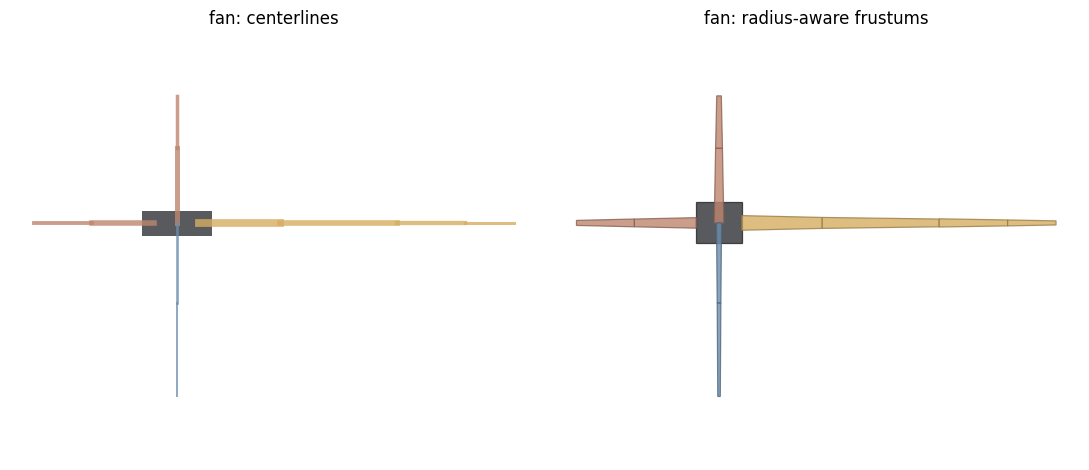

In [3]:
LAYOUT = "fan"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
vis.plot2d(morpho, layout=LAYOUT, shape="line", ax=axes[0])
axes[0].set_title(f"{LAYOUT}: centerlines")
vis.plot2d(morpho, layout=LAYOUT, shape="frustum", ax=axes[1])
axes[1].set_title(f"{LAYOUT}: radius-aware frustums")
fig.tight_layout()
plt.show()


## 3. Styling and theme scope

| Mechanism | Scope | Restoration |
| --- | --- | --- |
| Per-call keywords | One render | Automatic |
| `vis.theme(...)` | One `with` block | Automatic on exit |
| `vis.configure_defaults(...)` | Process-wide | Call `vis.reset_defaults()` explicitly |
| `vis.publication_theme()` | One `with` block | Restores vis defaults and Matplotlib `rcParams` |

Per-call controls include `branch_type_colors`,
`branch_type_edge_colors_2d`, and `frustum_edge_linewidth_2d`. Themes also
control 2-D/3-D alpha, Region highlight styling, and Locset marker styling.


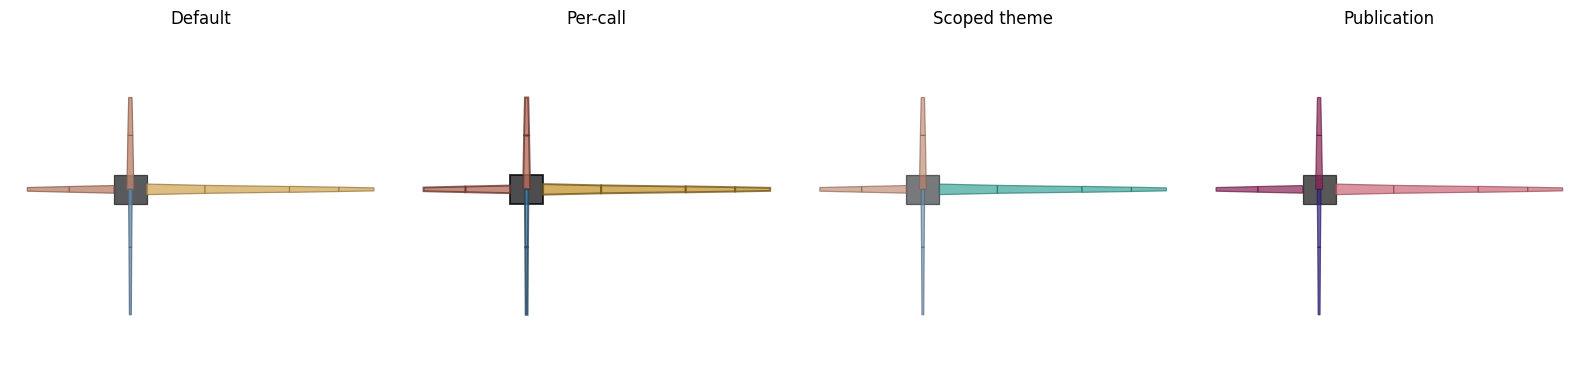

In [4]:
custom_fill = {
    "soma": "#202124",
    "axon": "#4f83a8",
    "basal_dendrite": "#b76e5d",
    "apical_dendrite": "#c89b3c",
}
custom_edges = {
    "soma": "#050607",
    "axon": "#24445b",
    "basal_dendrite": "#66352c",
    "apical_dendrite": "#725619",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vis.plot2d(morpho, layout="fan", shape="frustum", ax=axes[0])
axes[0].set_title("Default")

vis.plot2d(
    morpho,
    layout="fan",
    shape="frustum",
    branch_type_colors=custom_fill,
    branch_type_edge_colors_2d=custom_edges,
    frustum_edge_linewidth_2d=1.4,
    ax=axes[1],
)
axes[1].set_title("Per-call")

with vis.theme(branch_type_colors={"apical_dendrite": "#2a9d8f"}, alpha_2d=0.65):
    vis.plot2d(morpho, layout="fan", shape="frustum", ax=axes[2])
axes[2].set_title("Scoped theme")

with vis.publication_theme():
    vis.plot2d(morpho, layout="fan", shape="frustum", ax=axes[3])
axes[3].set_title("Publication")

fig.tight_layout()
plt.show()


## 4. Scalar values and selection overlays

`values` accepts one scalar per branch, per segment, or per centerline point.
`brainunit.Quantity` inputs contribute their unit to the colorbar label.

| Value length | Interpretation |
| --- | --- |
| `n_branches` | One constant value per branch |
| Total segment count | Piecewise value along each branch |
| Total centerline-point count | Values interpolated along every centerline |

Regions produce highlighted cable strokes; Locsets produce point markers. They
can be rendered together on the same morphology.


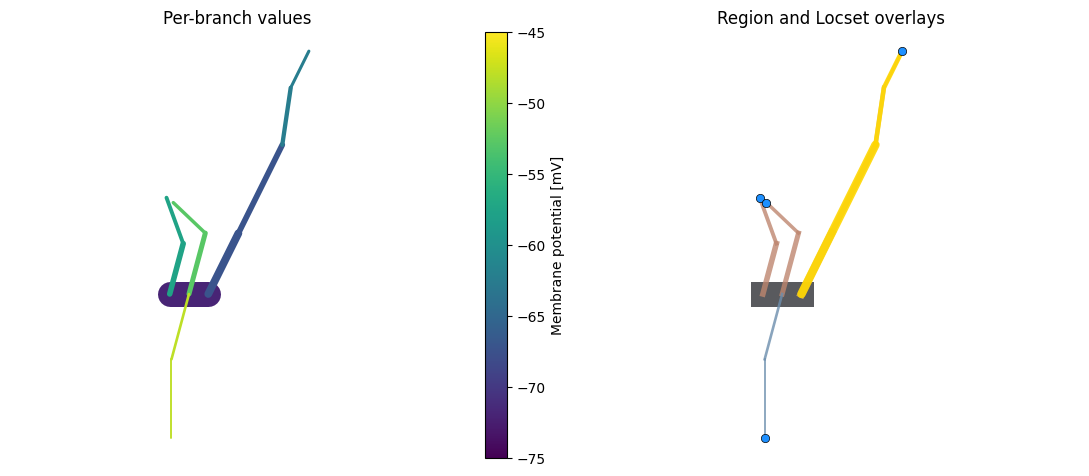

In [5]:
branch_voltage = np.linspace(-72.0, -48.0, len(morpho.branches)) * u.mV
apical_region = BranchInFilter("type", "apical_dendrite")
terminal_locset = Terminals()
apical_mask = morpho.select(apical_region)
terminal_mask = morpho.select(terminal_locset)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
vis.plot2d(
    morpho,
    layout="stem",
    shape="line",
    values=branch_voltage,
    cmap="viridis",
    vmin=-75.0,
    vmax=-45.0,
    value_label="Membrane potential",
    ax=axes[0],
)
axes[0].set_title("Per-branch values")

vis.plot2d(
    morpho,
    layout="stem",
    shape="line",
    region=apical_mask,
    locset=terminal_mask,
    ax=axes[1],
)
axes[1].set_title("Region and Locset overlays")
fig.tight_layout()
plt.show()


## 5. Guarded 3-D visualization

| Choice | Meaning |
| --- | --- |
| `mode="geometry"` | Radius-aware morphology geometry |
| `mode="skeleton"` | Lightweight centerline representation |
| `backend="pyvista"` | High-fidelity interactive rendering and screenshots/HTML |
| `backend="plotly"` | Browser-friendly interactive rendering |

Unlike `plot2d`, `plot3d` has no `layout`, `shape`, `projection_plane`, or
Matplotlib `ax`. Both functions share Region/Locset overlays, scalar values,
color normalization, and `VisHooks`.


<interactive PyVista scene>
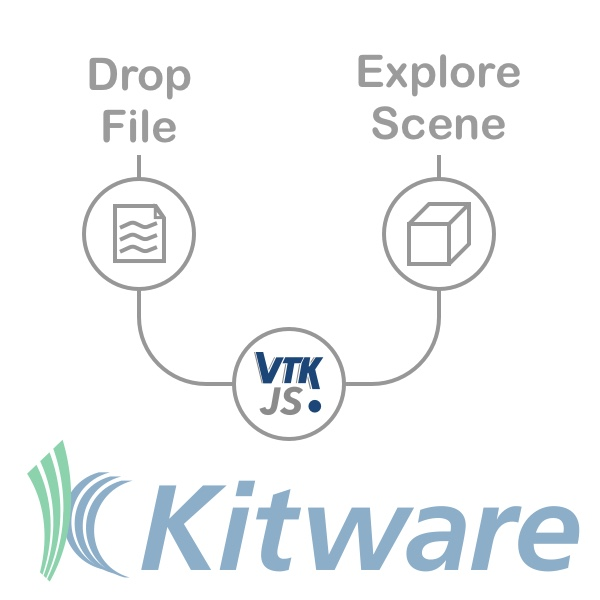

In [6]:
if HAS_PYVISTA:
    view_3d = vis.plot3d(
        morpho,
        mode="geometry",
        backend="pyvista",
        notebook=True,
        jupyter_backend="html",
    )
    display(view_3d)
elif HAS_PLOTLY:
    view_3d = vis.plot3d(morpho, mode="geometry", backend="plotly")
    display(view_3d)
else:
    print("Skipping 3-D rendering: install braincell[vis] for PyVista or Plotly.")


## 6. Cell runtime topology

Geometry views answer where cable exists in space. Cell topology views answer
how initialized runtime nodes, CVs, and branches connect.

| Level | Region | Locset | Runtime value | Coverage mode |
| --- | --- | --- | --- | --- |
| `node` | yes | yes | yes | yes |
| `cv` | yes | yes | yes | yes |
| `branch` | yes | no | no | yes |

Region coverage modes are `fraction` (blend by overlap), `any` (any overlap is
fully highlighted), and `all` (only complete coverage is highlighted). Highlight
mode and value mode are mutually exclusive for node and CV views.


n_nodes: 19 n_cv: 12 n_branches: 6


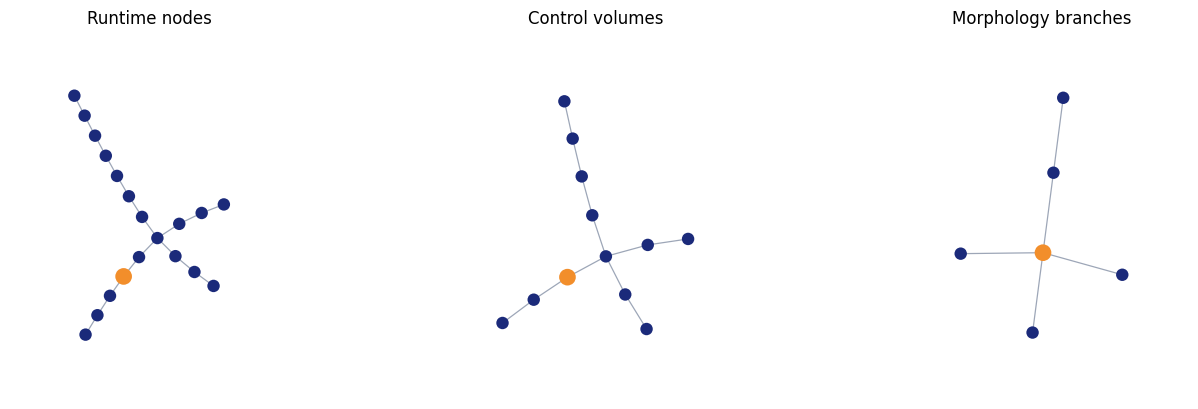

In [7]:
cell = Cell(morpho, cv_policy=CVPerBranch(2))
cell.paint(
    AllRegion(),
    mech.Channel("IL", g_max=0.08 * (u.mS / u.cm**2), E=-68.0 * u.mV),
)
cell.init_state()

print("n_nodes:", len(cell.node_tree.nodes), "n_cv:", cell.n_cv, "n_branches:", len(cell.morpho.branches))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
vis.plot_cell_topology(cell, layout="kamada_kawai", ax=axes[0])
axes[0].set_title("Runtime nodes")
vis.plot_cell_topology(cell, level="cv", layout="kamada_kawai", ax=axes[1])
axes[1].set_title("Control volumes")
vis.plot_cell_topology(cell, level="branch", layout="kamada_kawai", ax=axes[2])
axes[2].set_title("Morphology branches")
fig.tight_layout()
plt.show()


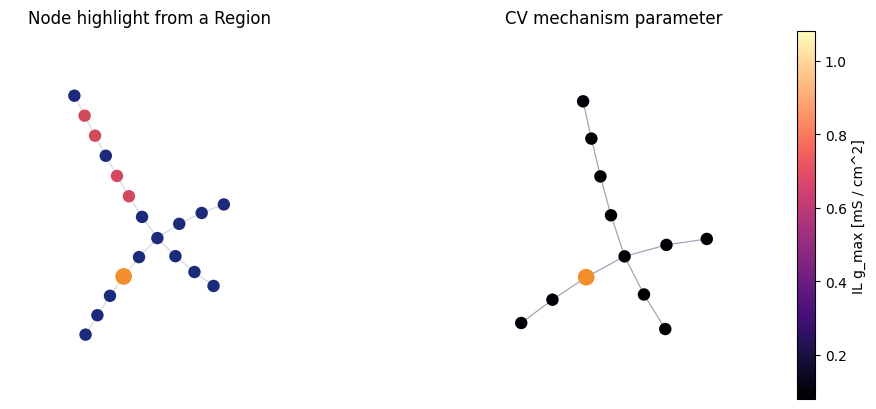

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
vis.plot_cell_topology(cell,
    region=apical_region,
    coverage_mode="fraction",
    highlight_color="#d1495b",
    layout="kamada_kawai",
    ax=axes[0],
)
axes[0].set_title("Node highlight from a Region")

vis.plot_cell_topology(cell, level="cv",
    value=("channel", "IL", "g_max"),
    cmap="magma",
    value_label="IL g_max",
    layout="kamada_kawai",
    ax=axes[1],
)
axes[1].set_title("CV mechanism parameter")
fig.tight_layout()
plt.show()


## 7. Animation and GIF export

`plot_movie` expects `(n_frames, N)` values, where `N` follows the same
branch/segment/point rules as static scalar values.

| Mode | Renderer | Output |
| --- | --- | --- |
| `dimensionality="2d"` | Matplotlib `FuncAnimation` | Inline, GIF, or MP4 |
| `dimensionality="3d"` | PyVista | Interactive plotter or MP4 |

`fps` controls playback speed; `dt` labels simulation time. The example below
creates and displays a real GIF when the Pillow writer is available. Otherwise
it falls back to an inline JavaScript animation.


frames: 24
wrote: /home/swl/braincell/data/vis_outputs/braincell_voltage.gif


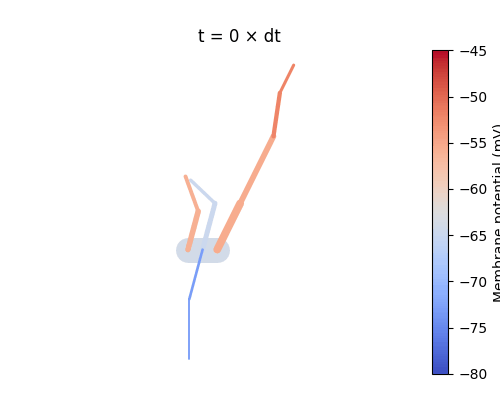

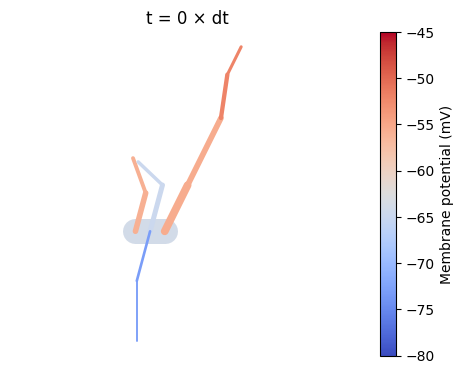

In [9]:
n_frames = 24
frame_phase = np.arange(n_frames, dtype=float)[:, None]
branch_phase = np.arange(len(morpho.branches), dtype=float)[None, :]
voltage_over_time = (
    -64.0 + 12.0 * np.sin(2.0 * np.pi * frame_phase / n_frames + 0.8 * branch_phase)
) * u.mV

gif_path = OUTPUT_DIR / "braincell_voltage.gif"
movie = vis.plot_movie(
    morpho,
    voltage_over_time,
    dt=0.5 * u.ms,
    dimensionality="2d",
    out=gif_path if HAS_PILLOW_WRITER else None,
    fps=12,
    layout="stem",
    shape="line",
    cmap="coolwarm",
    vmin=-80.0,
    vmax=-45.0,
    value_label="Membrane potential (mV)",
    figsize=(5.0, 4.2),
)

print("frames:", movie.frames)
if movie.output_path is not None:
    print("wrote:", movie.output_path)
    display(Image(filename=str(movie.output_path)))
else:
    print("Pillow writer unavailable; displaying an inline animation instead.")
    display(HTML(movie.animation.to_jshtml()))


## 8. Morphology-aligned traces

`plot_traces` expects a `(n_time, n_locations)` matrix. When a Locset is
supplied, the number and order of trace columns must match its points.

| Parameter | Purpose |
| --- | --- |
| `labels` | One label per trace panel |
| `colors` / `cmap` | Explicit colors or an automatic color sequence |
| `sharex` | Share the time axis among traces |
| `show_morphology` | Include or omit the marker-aligned morphology panel |


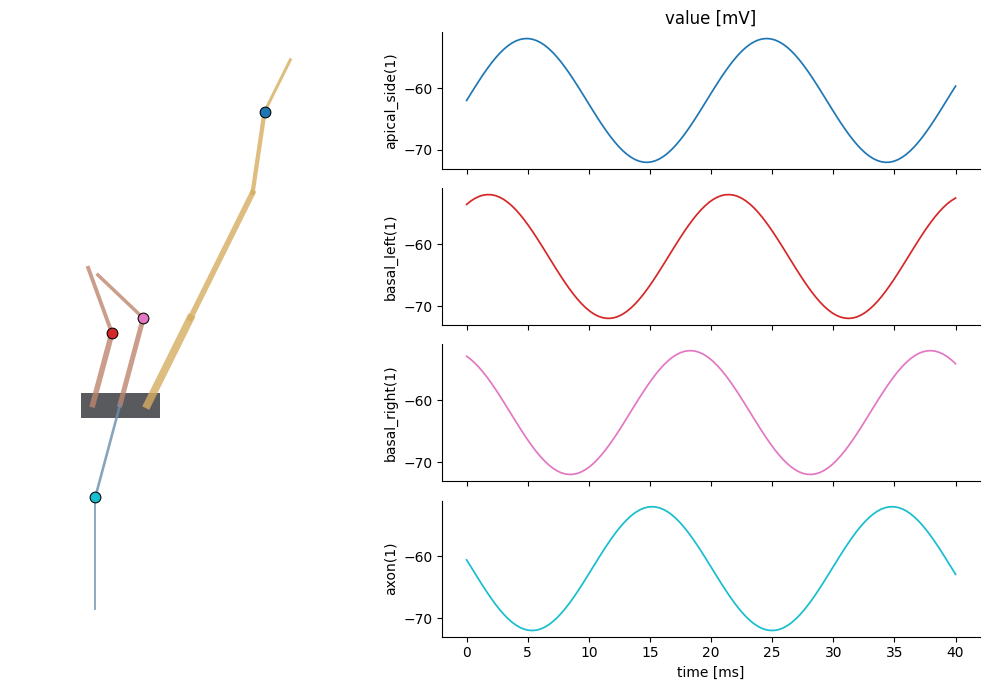

In [10]:
trace_sites = morpho.select(Terminals())
time = np.linspace(0.0, 40.0, 120) * u.ms
time_ms = time.to_decimal(u.ms)[:, None]
location_phase = np.arange(len(trace_sites.points), dtype=float)[None, :]
traces = (-62.0 + 10.0 * np.sin(0.32 * time_ms + location_phase)) * u.mV

trace_result = vis.plot_traces(
    morpho,
    time,
    traces,
    locset=trace_sites,
    labels=list(trace_sites.display_names),
    layout="stem",
    shape="line",
    value_unit_label="mV",
    figsize=(10, 7),
)
trace_result.figure.tight_layout()
plt.show()


## 9. Morphometry

| Plot | Question it answers | Main parameters |
| --- | --- | --- |
| `plot_dendrogram` | How are branches ordered and connected? | `color_by_type`, `linewidth` |
| `plot_topology` | What is the depth-only connectivity? | `color_by_type` |
| `plot_sholl` | How many neurites cross successive radii? | `step_um`, `max_radius_um` |
| `plot_branch_order_histogram` | How many branches occur at each order? | `color` |


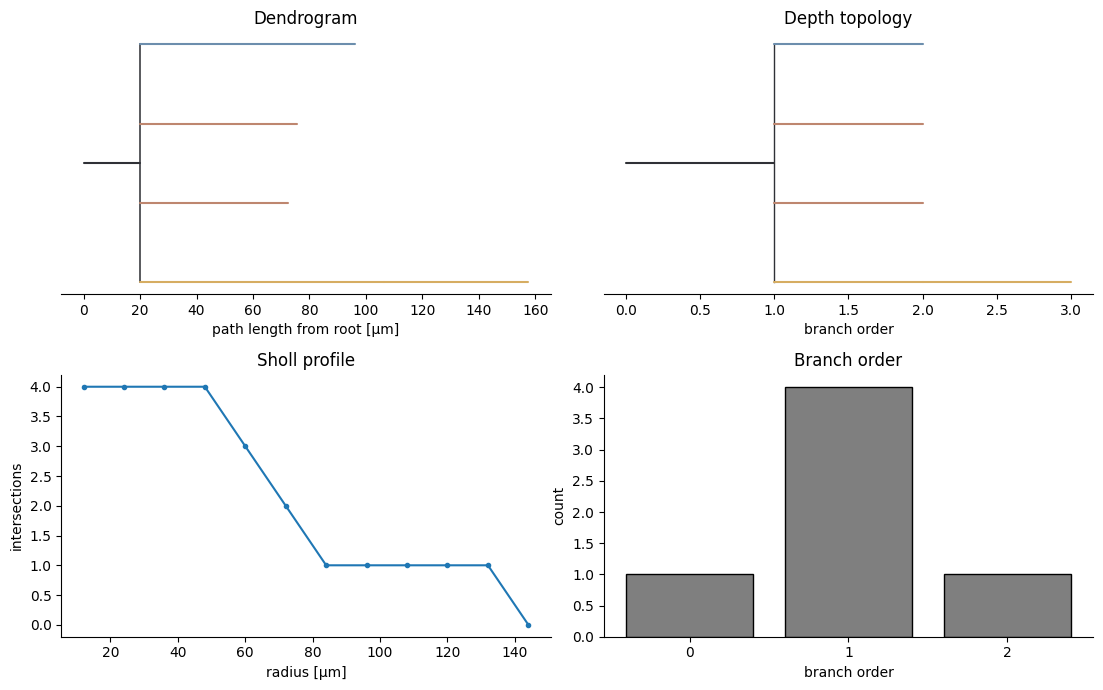

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
vis.plot_dendrogram(morpho, ax=axes[0, 0])
axes[0, 0].set_title("Dendrogram")
vis.plot_topology(morpho, ax=axes[0, 1])
axes[0, 1].set_title("Depth topology")
vis.plot_sholl(morpho, ax=axes[1, 0], step_um=12.0)
axes[1, 0].set_title("Sholl profile")
vis.plot_branch_order_histogram(morpho, ax=axes[1, 1])
axes[1, 1].set_title("Branch order")
fig.tight_layout()
plt.show()


## 10. Interactivity with `VisHooks`

| Callback | Matplotlib | PyVista |
| --- | --- | --- |
| `on_pick(info)` | yes | yes |
| `on_hover(info)` | yes | no |
| `on_leave()` | yes | no |

`PickInfo` reports the branch index/name/type, segment index, fractional
coordinate `x`, scene position, scalar value when present, and the backend
artist. Static notebook rendering creates the hook-enabled figure; callbacks
fire when an interactive notebook backend is active.


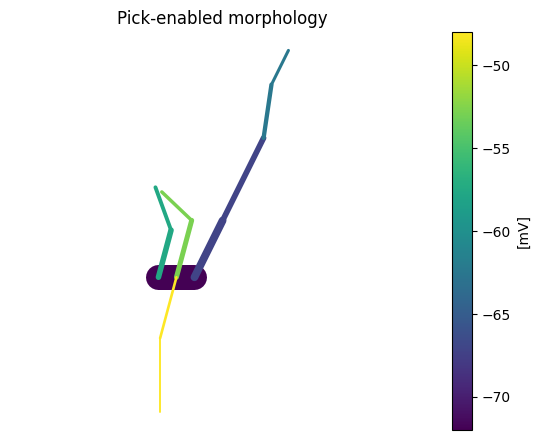

Use an interactive Matplotlib backend to click a branch.


In [12]:
picked = []


def report_pick(info):
    picked.append(info)
    print(
        f"branch={info.branch_name!r}, segment={info.segment_index}, "
        f"x={info.x}, value={info.value}"
    )


fig, ax = plt.subplots(figsize=(5.5, 4.5))
vis.plot2d(
    morpho,
    layout="stem",
    shape="line",
    values=branch_voltage,
    cmap="viridis",
    ax=ax,
    hooks=vis.VisHooks(on_pick=report_pick),
)
ax.set_title("Pick-enabled morphology")
fig.tight_layout()
plt.show()
print("Use an interactive Matplotlib backend to click a branch.")


## 11. Comparison and publication export

`compare_morphologies` compares geometry or topology variants with a shared
layout. `compare_values` compares scalar states on one morphology with a shared
color scale.

| Backend object | Raster | Vector | HTML |
| --- | --- | --- | --- |
| Matplotlib Axes/Figure | PNG/JPEG/TIFF | PDF/SVG/EPS | no |
| PyVista Plotter | PNG/JPEG/TIFF | backend-dependent | yes |
| Plotly Figure | PNG and other image formats with Kaleido | SVG/PDF with Kaleido | yes |

`save_figure` dispatches by the returned object type and destination suffix.


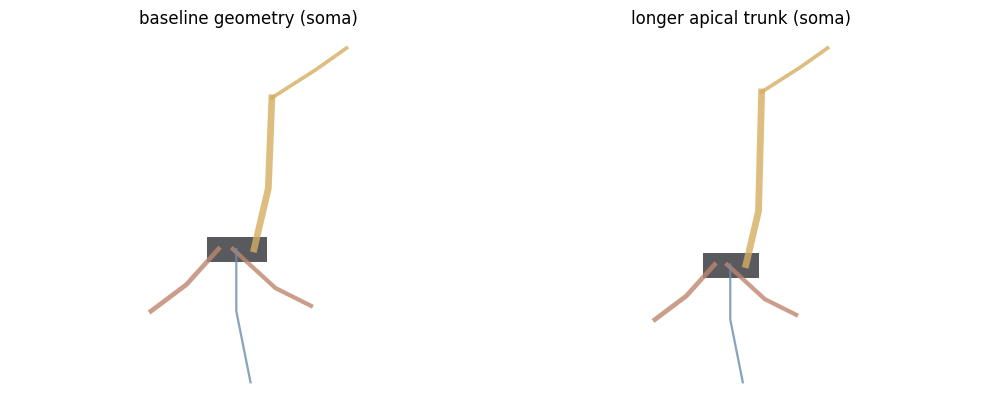

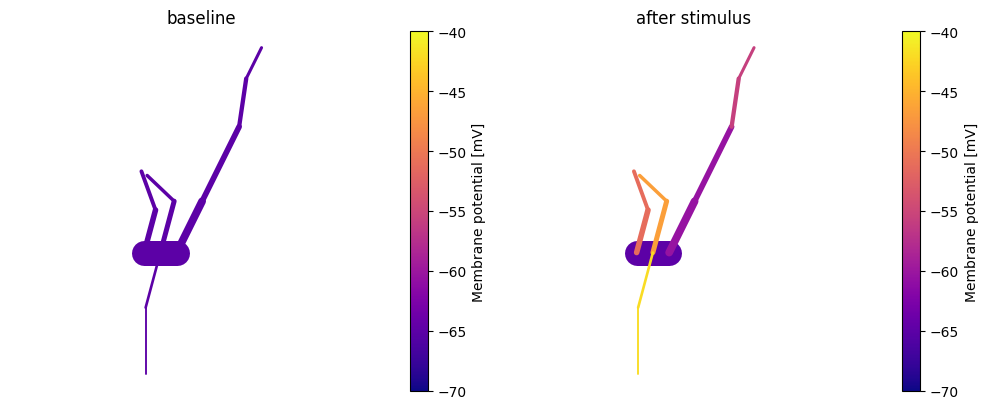

In [13]:
taller_apical = build_demo_morphology(apical_height=110.0)
fig, axes = vis.compare_morphologies(
    [morpho, taller_apical],
    titles=["baseline geometry", "longer apical trunk"],
    layout="projected",
    shape="line",
    figsize=(10, 4.2),
)
fig.tight_layout()
plt.show()

baseline = np.full(len(morpho.branches), -65.0) * u.mV
stimulated = np.linspace(-65.0, -42.0, len(morpho.branches)) * u.mV
fig, axes = vis.compare_values(
    morpho,
    [baseline, stimulated],
    titles=["baseline", "after stimulus"],
    cmap="plasma",
    vmin=-70.0,
    vmax=-40.0,
    value_label="Membrane potential",
    layout="stem",
    shape="line",
    figsize=(10, 4.2),
)
fig.tight_layout()
plt.show()


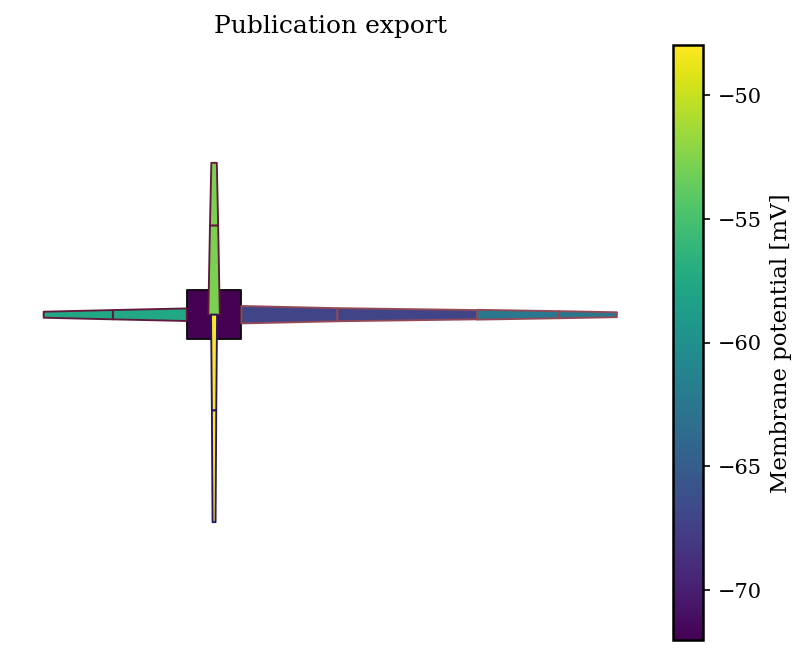

wrote: /home/swl/braincell/data/vis_outputs/braincell_morphology.pdf


In [15]:
pdf_path = OUTPUT_DIR / "braincell_morphology.pdf"
with vis.publication_theme():
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    vis.plot2d(
        morpho,
        layout="fan",
        shape="frustum",
        values=branch_voltage,
        cmap="viridis",
        value_label="Membrane potential",
        ax=ax,
    )
    ax.set_title("Publication export")
    fig.tight_layout()
    vis.save_figure(fig, pdf_path, dpi=300)
    plt.show()
print("wrote:", pdf_path)


## 12. Quick reference

| Task | Public entry point |
| --- | --- |
| Inspect morphology in 2-D/3-D | `vis.plot2d`, `vis.plot3d` |
| Inspect initialized runtime topology | `vis.plot_cell_topology(cell, level=...)` |
| Animate spatial values | `vis.plot_movie` |
| Align location traces with morphology | `vis.plot_traces` |
| Measure tree structure | `vis.plot_dendrogram`, `plot_topology`, `plot_sholl`, `plot_branch_order_histogram` |
| Add pick/hover behavior | `vis.VisHooks` |
| Compare models or values | `vis.compare_morphologies`, `vis.compare_values` |
| Produce publication output | `vis.publication_theme`, `vis.save_figure` |

The base 2-D workflow requires Matplotlib. Install the `vis` extra for
PyVista and Plotly 3-D backends. GIF export uses Pillow; video export uses an
FFmpeg writer available to Matplotlib or PyVista.
